# BSplineTokenizer Demo

This notebook demonstrates the `BSplineTokenizer` class for encoding multi-DoF robot trajectories as discrete tokens.

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from bspline_tokenizer import BSplineTokenizer, tokenize_trajectory

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
np.random.seed(42)

## 1. Basic Usage: Single DoF Trajectory

In [37]:
# Create a simple sine wave trajectory
n_timesteps = 50
t = np.linspace(0, 1, n_timesteps)
trajectory_1dof = np.sin(2 * np.pi * t).reshape(-1, 1)

# Create tokenizer for single DoF
tokenizer_1dof = BSplineTokenizer(
    n_dof=1,
    n_control_points=8,
    degree=4,
    bounds=(-1.5, 1.5),
    n_bins=256
)

print(tokenizer_1dof)

BSplineTokenizer(
  n_dof=1,
  n_control_points=8,
  degree=4,
  bounds=(-1.5, 1.5),
  n_bins=256,
  token_order='basis_first',
  vocab_size=256,
  n_tokens=8
)


Tokens: [128 160 231 227  28  24  95 127]
Token range: [24, 231]


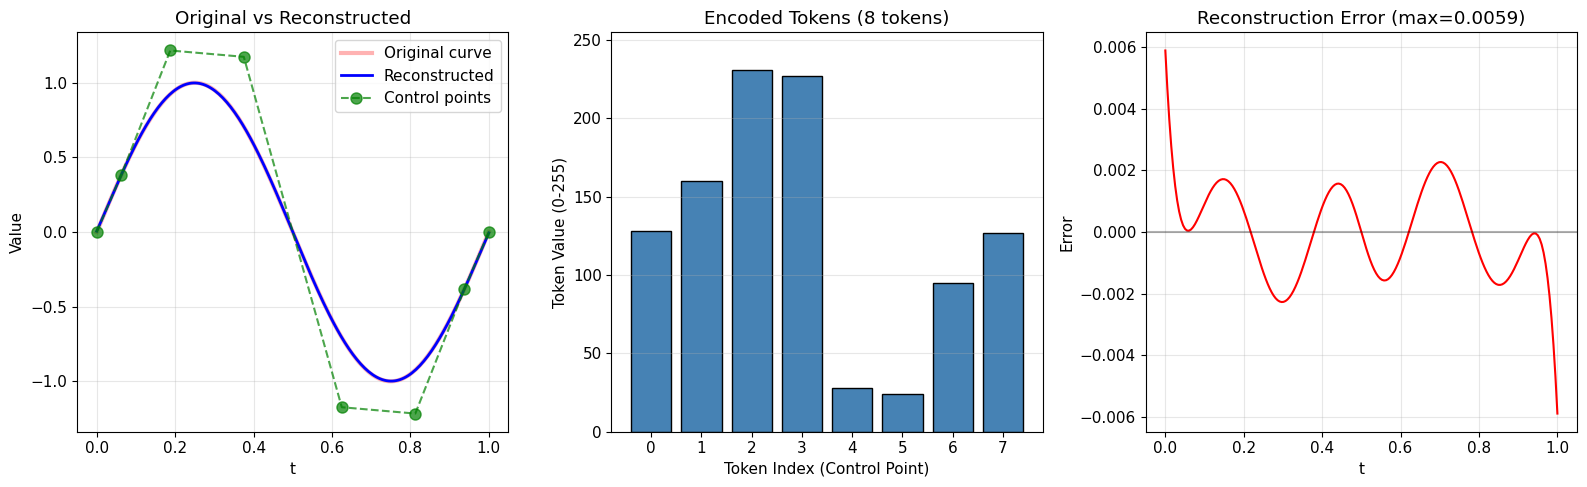

In [38]:
# Encode and decode
tokens = tokenizer_1dof.encode(t, trajectory_1dof)
print(f"Tokens: {tokens}")
print(f"Token range: [{tokens.min()}, {tokens.max()}]")

# Decode at higher resolution (chained call)
t_eval = np.linspace(0, 1, 200)
decoded_traj = tokenizer_1dof.decode(tokens)
reconstructed = decoded_traj.evaluate(t_eval)

# Get control points and knots for visualization using BSplineTrajectory.fit
from bspline_tokenizer.bspline_trajectory import BSplineTrajectory
fitted_traj = BSplineTrajectory.fit(t, trajectory_1dof, n_control_points=tokenizer_1dof.n_control_points, degree=tokenizer_1dof.degree, bounds=tokenizer_1dof.bounds)
control_points = fitted_traj.control_points
knots = fitted_traj.knots
degree = tokenizer_1dof.degree
n_cp = tokenizer_1dof.n_control_points

# Greville abscissae (x-positions for control points)
cp_t = np.array([np.mean(knots[i+1:i+degree+1]) for i in range(n_cp)])

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Original vs reconstructed
ax = axes[0]
ax.plot(t_eval, np.sin(2 * np.pi * t_eval), '-', color='red', linewidth=3, alpha=0.3, label='Original curve')
ax.plot(t_eval, reconstructed[:, 0], 'b-', linewidth=2, label='Reconstructed')
ax.plot(cp_t, control_points[0], 'g--o', markersize=8, alpha=0.7, label='Control points')
ax.set_xlabel('t')
ax.set_ylabel('Value')
ax.set_title('Original vs Reconstructed')
ax.legend()
ax.grid(True, alpha=0.3)

# Tokens visualization
ax = axes[1]
ax.bar(range(len(tokens)), tokens, color='steelblue', edgecolor='black')
ax.set_xlabel('Token Index (Control Point)')
ax.set_ylabel('Token Value (0-255)')
ax.set_title(f'Encoded Tokens ({len(tokens)} tokens)')
ax.set_ylim(0, 255)
ax.grid(True, alpha=0.3, axis='y')

# Reconstruction error
ax = axes[2]
true_vals = np.sin(2 * np.pi * t_eval)
error = reconstructed[:, 0] - true_vals
ax.plot(t_eval, error, 'r-', linewidth=1.5)
ax.axhline(0, color='black', linestyle='-', alpha=0.3)
ax.set_xlabel('t')
ax.set_ylabel('Error')
ax.set_title(f'Reconstruction Error (max={np.max(np.abs(error)):.4f})')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Multi-DoF Robot Trajectory (7-DoF Arm)

In [39]:
# Generate a realistic 7-DoF robot arm trajectory
n_dof = 7
n_timesteps = 50
t = np.linspace(0, 1, n_timesteps)

# Create diverse joint trajectories
trajectory_7dof = np.zeros((n_timesteps, n_dof))
joint_names = ['Shoulder Pan', 'Shoulder Lift', 'Elbow', 'Wrist 1', 'Wrist 2', 'Wrist 3', 'Gripper']

for dof in range(n_dof):
    freq = np.random.uniform(0.5, 2.0)
    phase = np.random.uniform(0, 2 * np.pi)
    amplitude = np.random.uniform(0.3, 0.8)
    offset = np.random.uniform(-0.2, 0.2)
    trajectory_7dof[:, dof] = amplitude * np.sin(2 * np.pi * freq * t + phase) + offset

print(f"Trajectory shape: {trajectory_7dof.shape}")
print(f"Value range: [{trajectory_7dof.min():.3f}, {trajectory_7dof.max():.3f}]")

Trajectory shape: (50, 7)
Value range: [-0.626, 0.705]


In [40]:
# Create tokenizer
tokenizer = BSplineTokenizer(
    n_dof=7,
    n_control_points=8,
    degree=4,
    bounds=(-1.5, 1.5),
    n_bins=256,
    token_order='basis_first'
)

print(tokenizer)

# Encode
tokens = tokenizer.encode(t, trajectory_7dof)
print(f"\nEncoded to {len(tokens)} tokens")
print(f"Token sequence: {tokens}")

BSplineTokenizer(
  n_dof=7,
  n_control_points=8,
  degree=4,
  bounds=(-1.5, 1.5),
  n_bins=256,
  token_order='basis_first',
  vocab_size=256,
  n_tokens=56
)

Encoded to 56 tokens
Token sequence: [114 163 118 149 114 152  95 135 168 114 163  98 164  98 192 172 128  94
  66 172 125 212 155 213  36  74  31 197  65 116 112 244 169 133 119  60
 107 105  41 174 194  75 113 116 151  91 142 125 107 135 122 160 109 126
 110 121]


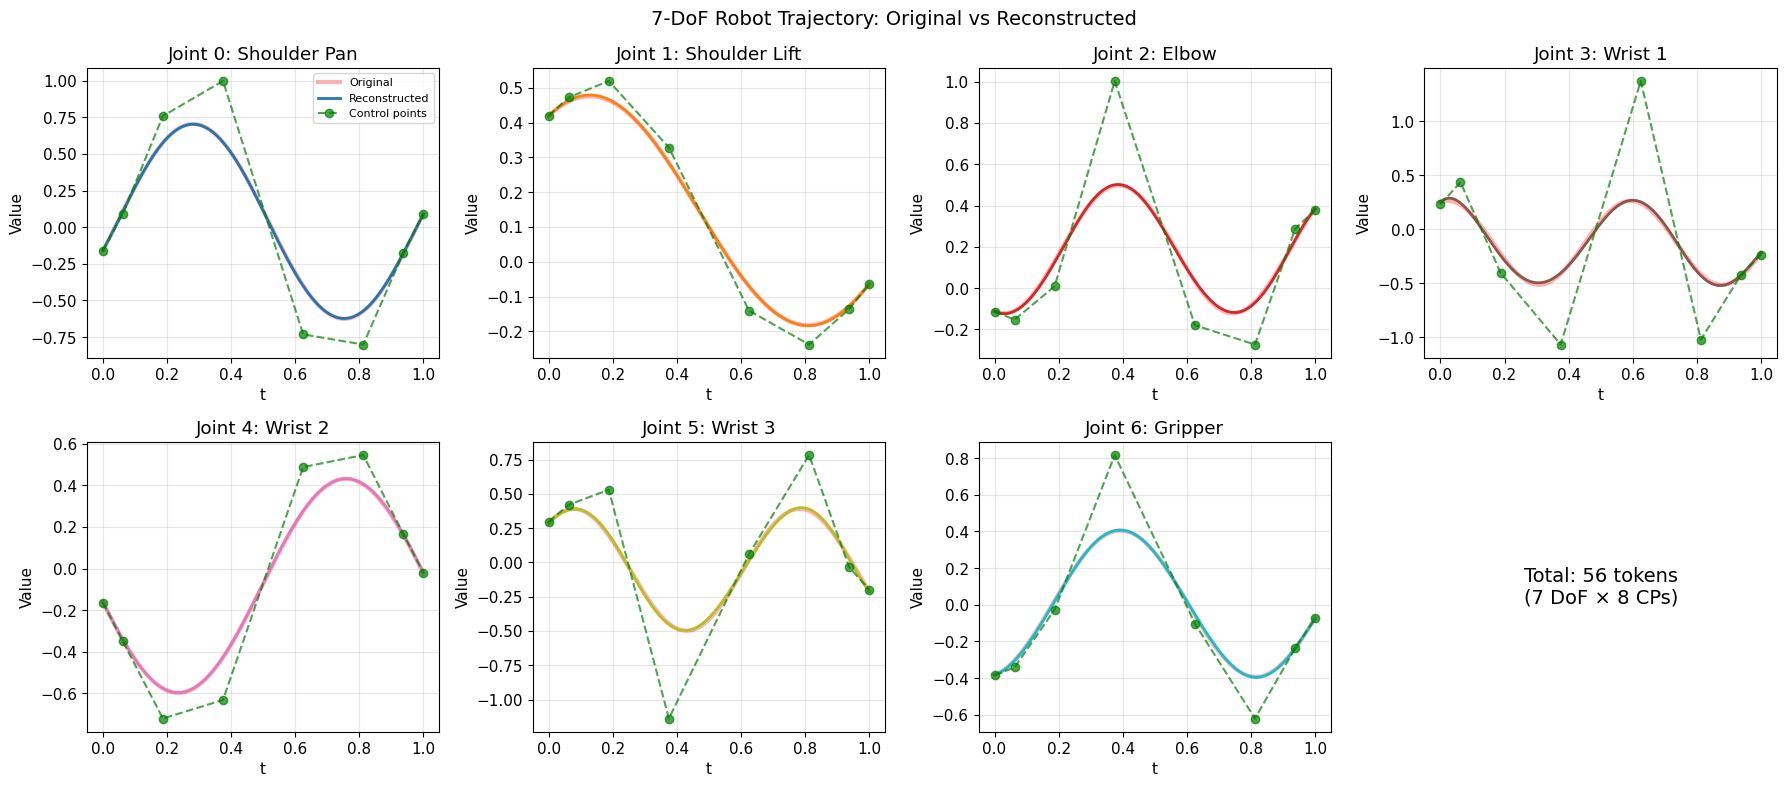

In [41]:
# Decode and visualize all joints
t_eval = np.linspace(0, 1, 200)
reconstructed = tokenizer.decode(tokens).evaluate(t_eval)

# Get control points and knots using BSplineTrajectory.fit
from bspline_tokenizer.bspline_trajectory import BSplineTrajectory
fitted_traj = BSplineTrajectory.fit(t, trajectory_7dof, n_control_points=tokenizer.n_control_points, degree=tokenizer.degree, bounds=tokenizer.bounds)
control_points = fitted_traj.control_points
knots = fitted_traj.knots
degree = tokenizer.degree
n_cp = tokenizer.n_control_points
cp_t = np.array([np.mean(knots[i+1:i+degree+1]) for i in range(n_cp)])

# Interpolate original for smooth plotting
trajectory_interp = np.zeros((len(t_eval), n_dof))
for dof in range(n_dof):
    trajectory_interp[:, dof] = np.interp(t_eval, t, trajectory_7dof[:, dof])

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

colors = plt.cm.tab10(np.linspace(0, 1, n_dof))

for dof in range(n_dof):
    ax = axes[dof]
    # Original as transparent red line
    ax.plot(t_eval, trajectory_interp[:, dof], '-', color='red', linewidth=3, alpha=0.3, label='Original')
    # Reconstructed as solid blue line
    ax.plot(t_eval, reconstructed[:, dof], '-', color=colors[dof], linewidth=2, label='Reconstructed')
    # Control points
    ax.plot(cp_t, control_points[dof], 'g--o', markersize=6, alpha=0.7, label='Control points')
    ax.set_xlabel('t')
    ax.set_ylabel('Value')
    ax.set_title(f'Joint {dof}: {joint_names[dof]}')
    ax.grid(True, alpha=0.3)
    if dof == 0:
        ax.legend(fontsize=8)

# Hide unused subplot
axes[7].axis('off')
axes[7].text(0.5, 0.5, f'Total: {len(tokens)} tokens\n({n_dof} DoF × {tokenizer.n_control_points} CPs)',
             ha='center', va='center', fontsize=14, transform=axes[7].transAxes)

plt.suptitle('7-DoF Robot Trajectory: Original vs Reconstructed', fontsize=14)
plt.tight_layout()
plt.show()

In [42]:
# Compute and display errors
errors = tokenizer.compute_reconstruction_error(t, trajectory_7dof, t_eval)

print("Reconstruction Error Summary:")
print(f"  Overall MAE: {errors['mae']:.6f}")
print(f"  Overall Max Error: {errors['max_error']:.6f}")
print(f"  Overall RMSE: {errors['rmse']:.6f}")
print(f"\nPer-Joint MAE:")
for dof, (name, mae) in enumerate(zip(joint_names, errors['mae_per_dof'])):
    print(f"  {name}: {mae:.6f}")

Reconstruction Error Summary:
  Overall MAE: 0.004425
  Overall Max Error: 0.027050
  Overall RMSE: 0.006757

Per-Joint MAE:
  Shoulder Pan: 0.001879
  Shoulder Lift: 0.001099
  Elbow: 0.003620
  Wrist 1: 0.013189
  Wrist 2: 0.001914
  Wrist 3: 0.006852
  Gripper: 0.002425


## 3. Token Ordering Comparison

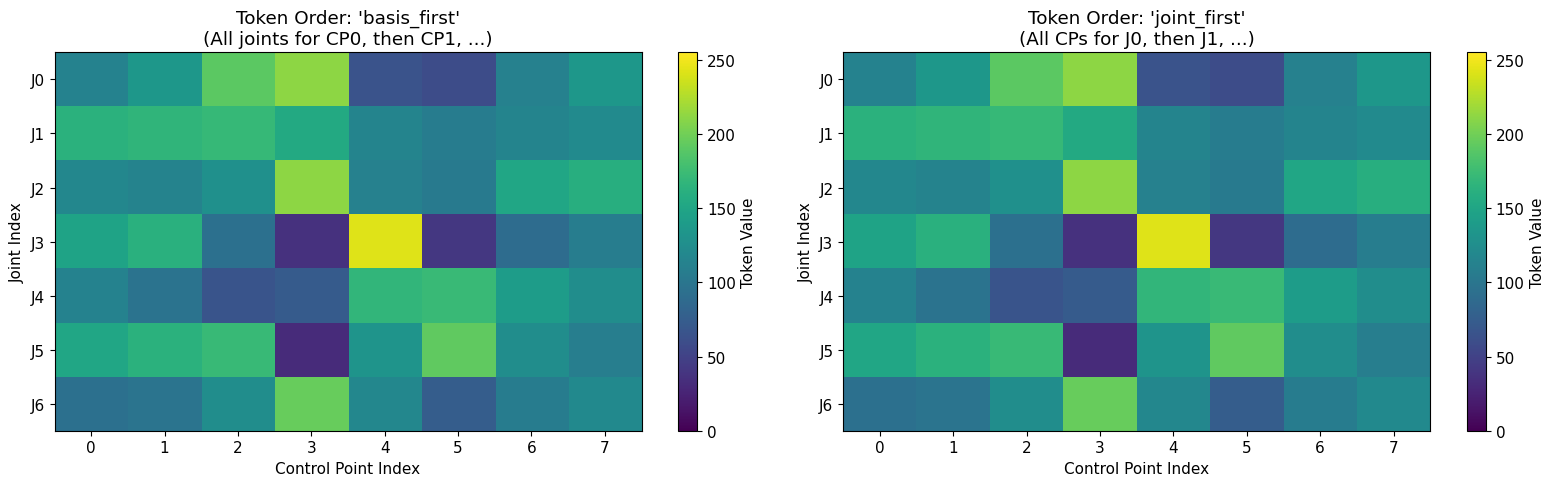

Token sequence comparison (first 21 tokens):

basis_first: [113 163 118 148 113 151  94 135 167 114 162  97 163  98 191 171 128  94
  66 172 125]
  Layout: [CP0_J0, CP0_J1, CP0_J2, ..., CP0_J6, CP1_J0, CP1_J1, ...]

joint_first: [113 135 191 212  65  59 112 135 163 167 171 155 115 107 115 122 118 114
 128 212 112]
  Layout: [CP0_J0, CP1_J0, CP2_J0, ..., CP7_J0, CP0_J1, CP1_J1, ...]


In [43]:
# Compare the two token orderings
tokenizer_basis = BSplineTokenizer(n_dof=7, n_control_points=8, token_order='basis_first')
tokenizer_joint = BSplineTokenizer(n_dof=7, n_control_points=8, token_order='joint_first')

tokens_basis = tokenizer_basis.encode(t, trajectory_7dof)
tokens_joint = tokenizer_joint.encode(t, trajectory_7dof)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Reshape tokens for visualization
n_cp = 8

# Basis-first: shape (n_cp, n_dof)
tokens_basis_2d = tokens_basis.reshape(n_cp, n_dof)

# Joint-first: shape (n_dof, n_cp)
tokens_joint_2d = tokens_joint.reshape(n_dof, n_cp)

ax = axes[0]
im = ax.imshow(tokens_basis_2d.T, aspect='auto', cmap='viridis', vmin=0, vmax=255)
ax.set_xlabel('Control Point Index')
ax.set_ylabel('Joint Index')
ax.set_title("Token Order: 'basis_first'\n(All joints for CP0, then CP1, ...)")
ax.set_xticks(range(n_cp))
ax.set_yticks(range(n_dof))
ax.set_yticklabels([f'J{i}' for i in range(n_dof)])
plt.colorbar(im, ax=ax, label='Token Value')

ax = axes[1]
im = ax.imshow(tokens_joint_2d, aspect='auto', cmap='viridis', vmin=0, vmax=255)
ax.set_xlabel('Control Point Index')
ax.set_ylabel('Joint Index')
ax.set_title("Token Order: 'joint_first'\n(All CPs for J0, then J1, ...)")
ax.set_xticks(range(n_cp))
ax.set_yticks(range(n_dof))
ax.set_yticklabels([f'J{i}' for i in range(n_dof)])
plt.colorbar(im, ax=ax, label='Token Value')

plt.tight_layout()
plt.show()

print("Token sequence comparison (first 21 tokens):")
print(f"\nbasis_first: {tokens_basis[:21]}")
print(f"  Layout: [CP0_J0, CP0_J1, CP0_J2, ..., CP0_J6, CP1_J0, CP1_J1, ...]")
print(f"\njoint_first: {tokens_joint[:21]}")
print(f"  Layout: [CP0_J0, CP1_J0, CP2_J0, ..., CP7_J0, CP0_J1, CP1_J1, ...]")

## 4. Effect of Number of Control Points

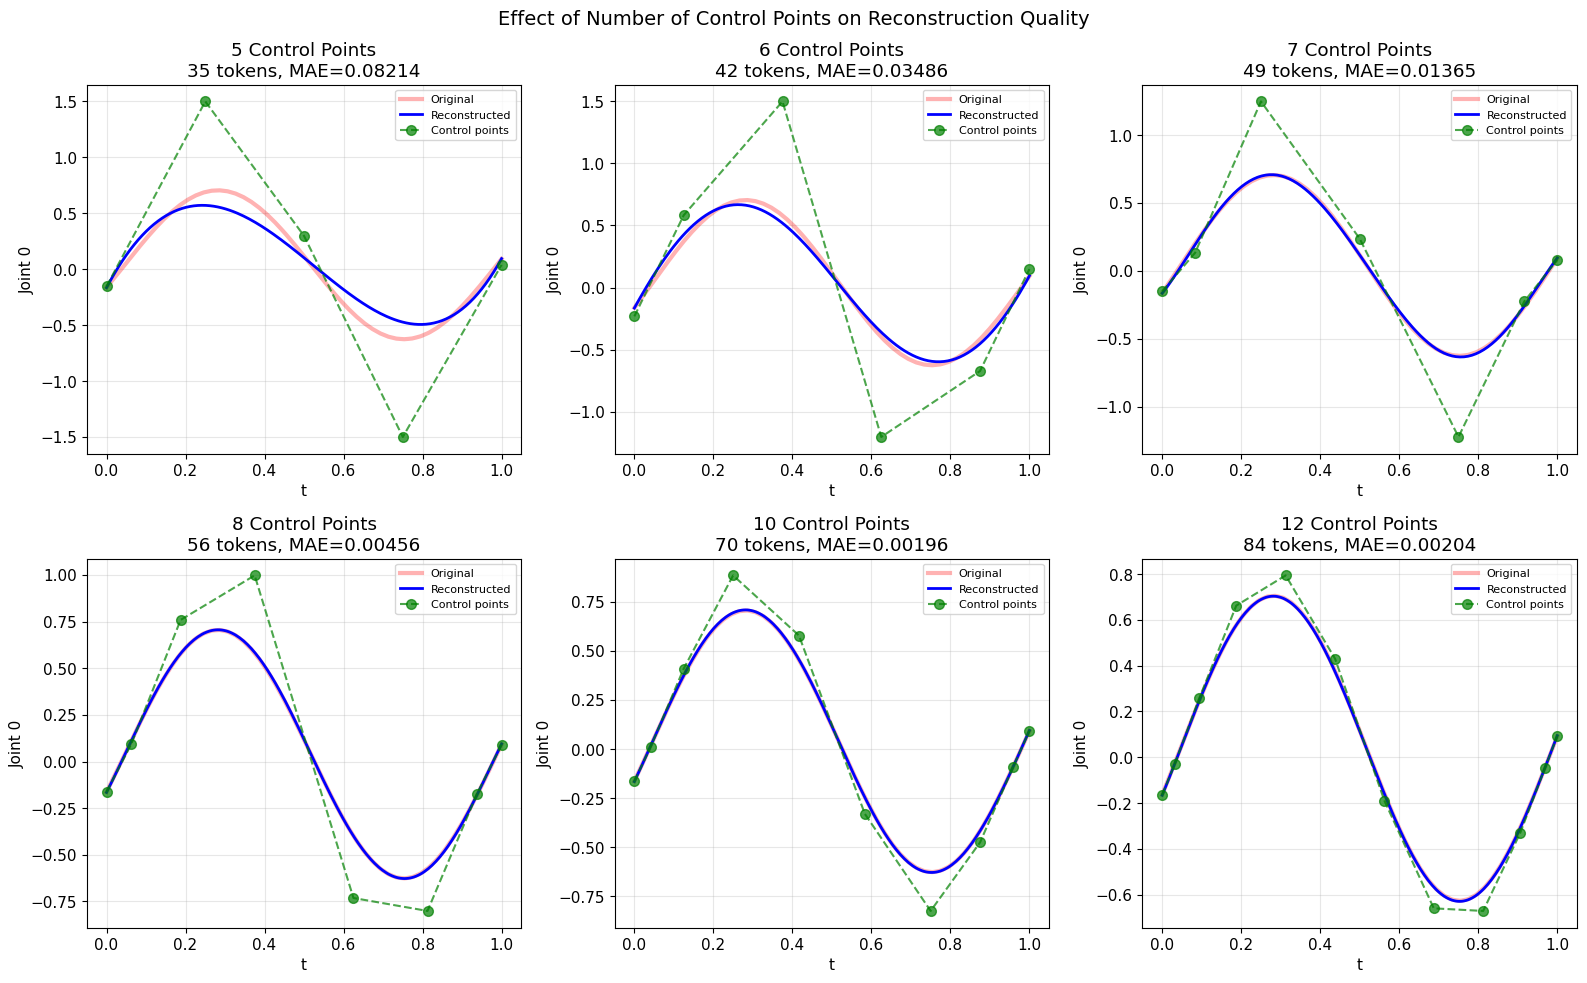

In [44]:
# Test different numbers of control points
cp_values = [5, 6, 7, 8, 10, 12]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

errors_by_cp = []

# Interpolate original for plotting
traj_interp_j0 = np.interp(t_eval, t, trajectory_7dof[:, 0])

for idx, n_cp in enumerate(cp_values):
    tok = BSplineTokenizer(n_dof=7, n_control_points=n_cp, degree=4)
    tokens = tok.encode(t, trajectory_7dof)
    recon = tok.decode(tokens).evaluate(t_eval)
    
    # Get control points for joint 0 using BSplineTrajectory.fit
    fitted_traj = BSplineTrajectory.fit(t, trajectory_7dof, n_control_points=n_cp, degree=4, bounds=tok.bounds)
    cp = fitted_traj.control_points
    cp_t = np.array([np.mean(fitted_traj.knots[i+1:i+tok.degree+1]) for i in range(n_cp)])
    
    err = tok.compute_reconstruction_error(t, trajectory_7dof, t_eval)
    errors_by_cp.append(err['mae'])
    
    ax = axes[idx]
    # Original as transparent red line
    ax.plot(t_eval, traj_interp_j0, '-', color='red', linewidth=3, alpha=0.3, label='Original')
    # Reconstructed
    ax.plot(t_eval, recon[:, 0], 'b-', linewidth=2, label='Reconstructed')
    # Control points
    ax.plot(cp_t, cp[0], 'g--o', markersize=7, alpha=0.7, label='Control points')
    ax.set_title(f'{n_cp} Control Points\n{len(tokens)} tokens, MAE={err["mae"]:.5f}')
    ax.set_xlabel('t')
    ax.set_ylabel('Joint 0')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle('Effect of Number of Control Points on Reconstruction Quality', fontsize=14)
plt.tight_layout()
plt.show()

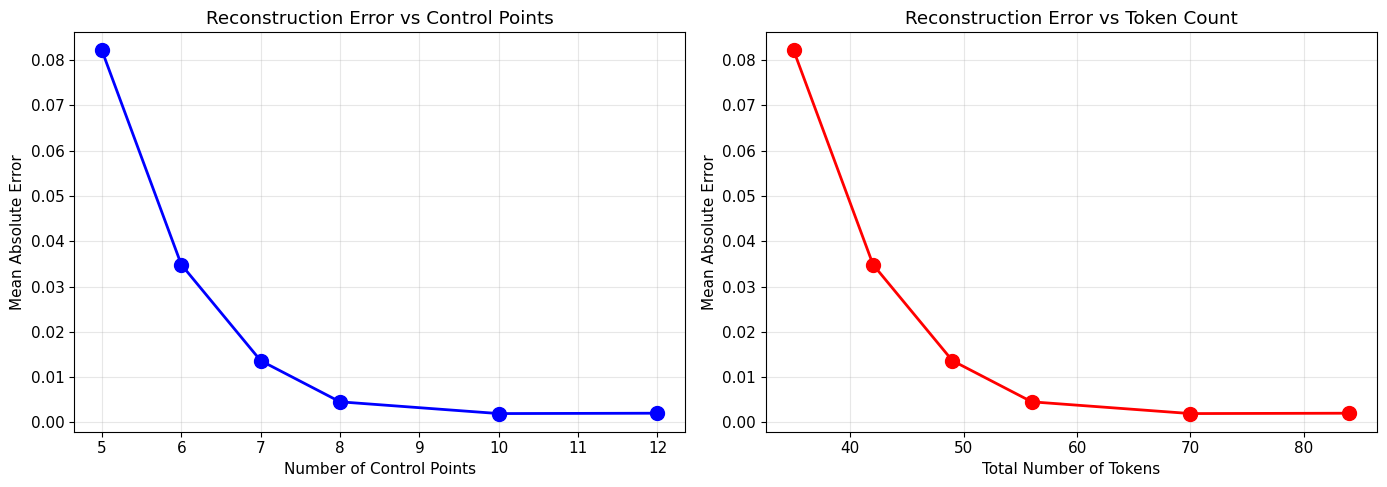

Summary:
Control Points   Total Tokens   MAE         
------------------------------------------
5                35             0.082140    
6                42             0.034857    
7                49             0.013645    
8                56             0.004557    
10               70             0.001962    
12               84             0.002041    


In [45]:
# Plot error vs number of control points
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(cp_values, errors_by_cp, 'bo-', linewidth=2, markersize=10)
ax.set_xlabel('Number of Control Points')
ax.set_ylabel('Mean Absolute Error')
ax.set_title('Reconstruction Error vs Control Points')
ax.grid(True, alpha=0.3)

ax = axes[1]
n_tokens = [7 * n_cp for n_cp in cp_values]
ax.plot(n_tokens, errors_by_cp, 'ro-', linewidth=2, markersize=10)
ax.set_xlabel('Total Number of Tokens')
ax.set_ylabel('Mean Absolute Error')
ax.set_title('Reconstruction Error vs Token Count')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Summary:")
print(f"{'Control Points':<16} {'Total Tokens':<14} {'MAE':<12}")
print("-" * 42)
for n_cp, err in zip(cp_values, errors_by_cp):
    print(f"{n_cp:<16} {7*n_cp:<14} {err:<12.6f}")

## 5. Quantization Visualization

Control points shape: (7, 8)
Control points range: [-1.1390, 1.3727]


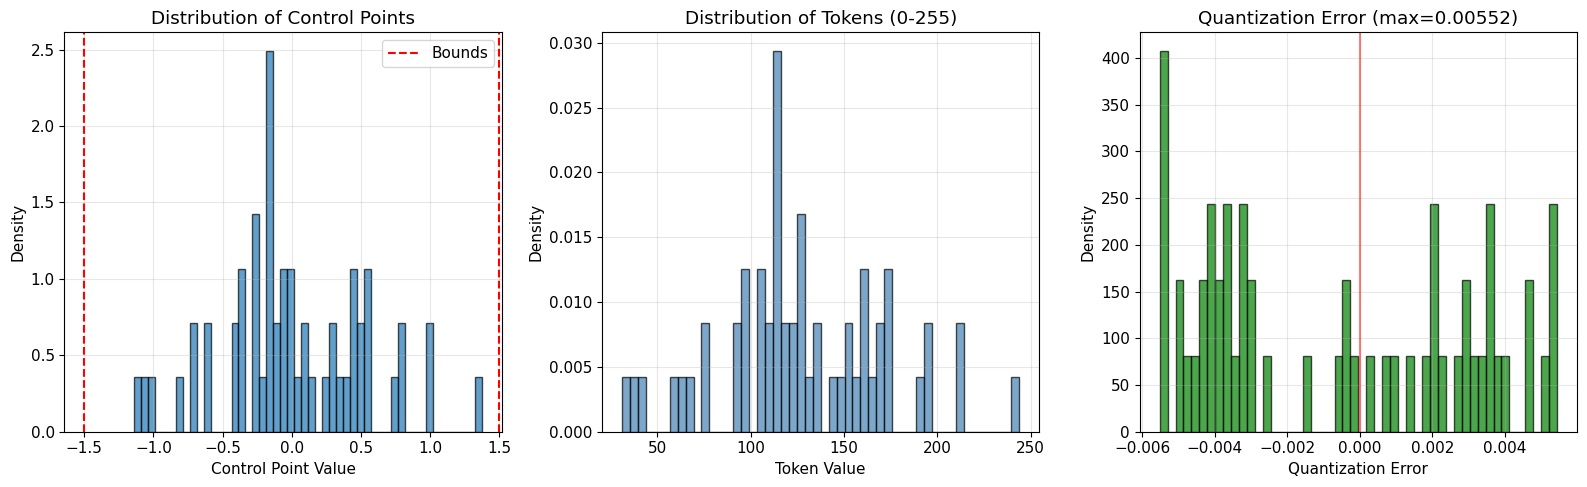

In [46]:
# Visualize the quantization process
tokenizer = BSplineTokenizer(n_dof=7, n_control_points=8, bounds=(-1.5, 1.5), n_bins=256)

# Get control points before quantization using BSplineTrajectory.fit
from bspline_tokenizer.bspline_trajectory import BSplineTrajectory
control_points = BSplineTrajectory.fit(t, trajectory_7dof, n_control_points=tokenizer.n_control_points, degree=tokenizer.degree, bounds=tokenizer.bounds).control_points
print(f"Control points shape: {control_points.shape}")
print(f"Control points range: [{control_points.min():.4f}, {control_points.max():.4f}]")

# Quantize and dequantize
tokens = tokenizer.get_tokens_from_control_points(control_points)
control_points_reconstructed = tokenizer.get_control_points_from_tokens(tokens)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Control point distribution
ax = axes[0]
ax.hist(control_points.flatten(), bins=50, density=True, alpha=0.7, edgecolor='black')
ax.axvline(-1.5, color='red', linestyle='--', label='Bounds')
ax.axvline(1.5, color='red', linestyle='--')
ax.set_xlabel('Control Point Value')
ax.set_ylabel('Density')
ax.set_title('Distribution of Control Points')
ax.legend()
ax.grid(True, alpha=0.3)

# Token distribution
ax = axes[1]
ax.hist(tokens, bins=50, density=True, alpha=0.7, edgecolor='black', color='steelblue')
ax.set_xlabel('Token Value')
ax.set_ylabel('Density')
ax.set_title('Distribution of Tokens (0-255)')
ax.grid(True, alpha=0.3)

# Quantization error
ax = axes[2]
quant_error = (control_points - control_points_reconstructed).flatten()
ax.hist(quant_error, bins=50, density=True, alpha=0.7, edgecolor='black', color='green')
ax.axvline(0, color='red', linestyle='-', alpha=0.5)
ax.set_xlabel('Quantization Error')
ax.set_ylabel('Density')
ax.set_title(f'Quantization Error (max={np.max(np.abs(quant_error)):.5f})')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Different Trajectory Types

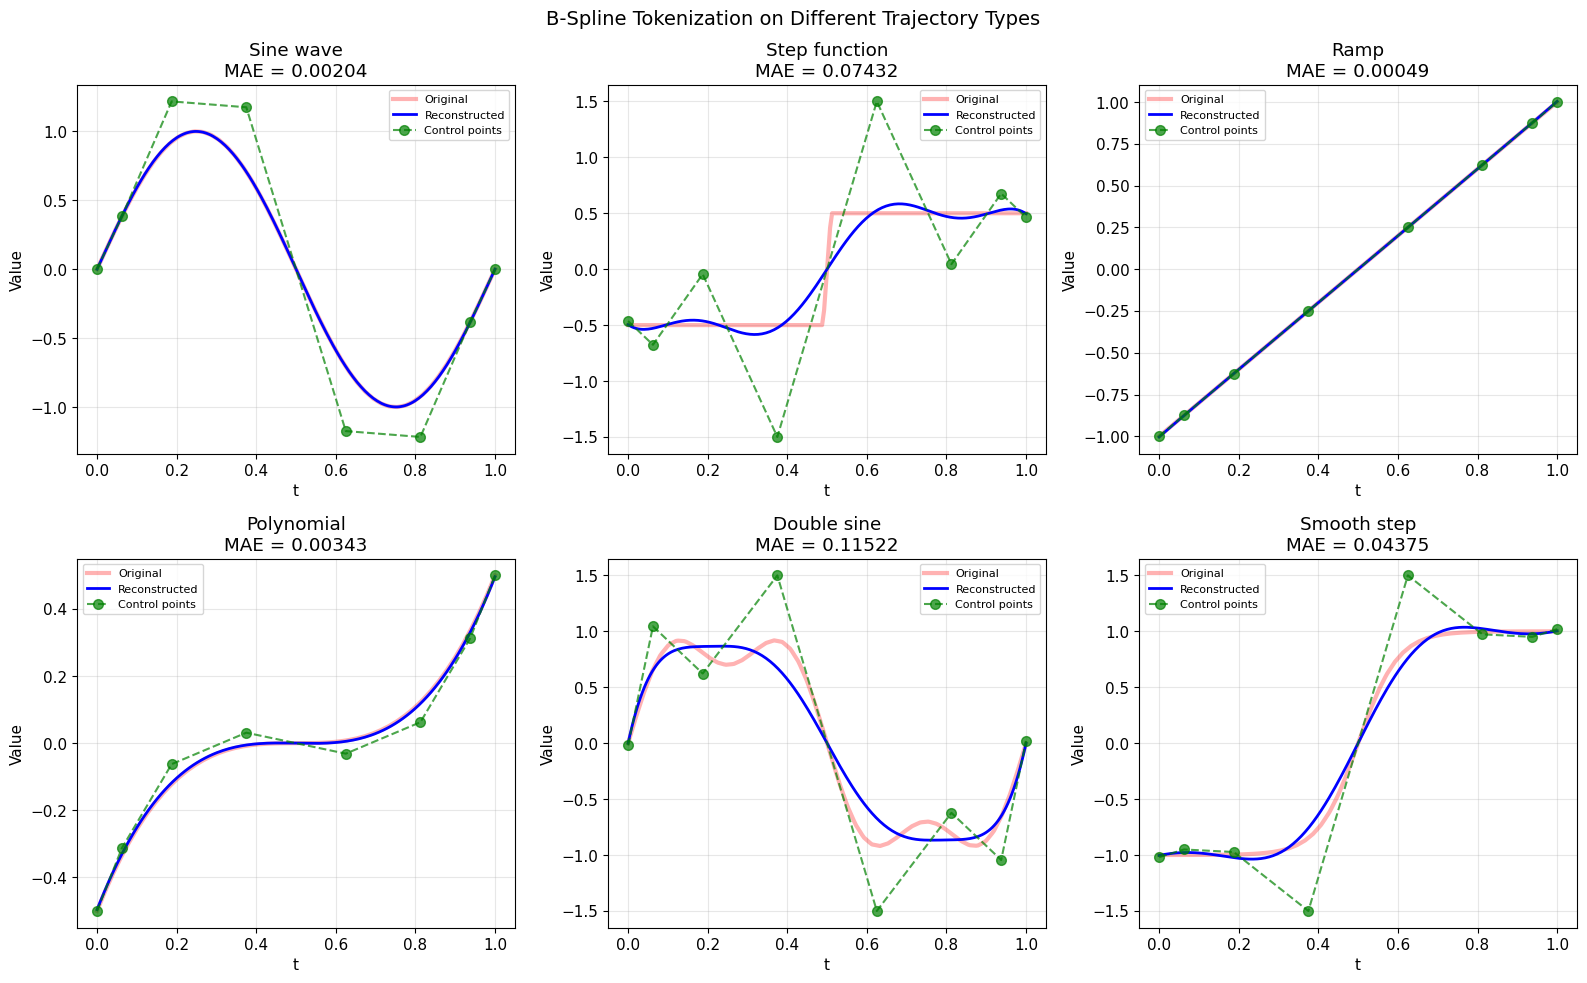

In [47]:
# Test on different trajectory types
t = np.linspace(0, 1, 50)
t_eval = np.linspace(0, 1, 200)

# Create different trajectory types (single DoF for visualization)
trajectories = {
    'Sine wave': np.sin(2 * np.pi * t),
    'Step function': np.where(t < 0.5, -0.5, 0.5),
    'Ramp': t * 2 - 1,
    'Polynomial': 4 * (t - 0.5)**3,
    'Double sine': np.sin(2 * np.pi * t) + 0.3 * np.sin(6 * np.pi * t),
    'Smooth step': np.tanh(10 * (t - 0.5))
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

tokenizer_1d = BSplineTokenizer(n_dof=1, n_control_points=8, degree=4)

for idx, (name, traj) in enumerate(trajectories.items()):
    traj_2d = traj.reshape(-1, 1)
    tokens = tokenizer_1d.encode(t, traj_2d)
    recon = tokenizer_1d.decode(tokens).evaluate(t_eval)
    
    # Get control points using BSplineTrajectory.fit
    fitted_traj = BSplineTrajectory.fit(t, traj_2d, n_control_points=tokenizer_1d.n_control_points, degree=tokenizer_1d.degree, bounds=tokenizer_1d.bounds)
    cp = fitted_traj.control_points
    cp_t = np.array([np.mean(fitted_traj.knots[i+1:i+tokenizer_1d.degree+1]) 
                    for i in range(tokenizer_1d.n_control_points)])
    
    # Interpolate original for smooth line
    traj_interp = np.interp(t_eval, t, traj)
    
    ax = axes[idx]
    # Original as transparent red line
    ax.plot(t_eval, traj_interp, '-', color='red', linewidth=3, alpha=0.3, label='Original')
    # Reconstructed
    ax.plot(t_eval, recon[:, 0], 'b-', linewidth=2, label='Reconstructed')
    # Control points
    ax.plot(cp_t, cp[0], 'g--o', markersize=7, alpha=0.7, label='Control points')
    
    # Compute error
    mae = np.mean(np.abs(recon[:, 0] - traj_interp))
    
    ax.set_title(f'{name}\nMAE = {mae:.5f}')
    ax.set_xlabel('t')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle('B-Spline Tokenization on Different Trajectory Types', fontsize=14)
plt.tight_layout()
plt.show()

## 6b. Pin Endpoints: Exact Start/End Matching

The `pin_endpoints` parameter (default `True`) ensures the reconstructed trajectory passes exactly through the first and last data points. This is important for robotics where the start and end poses must be exact.

Data endpoints: y[0] = 0.5, y[-1] = -0.8

With pin_endpoints=True:
  curve(0) = 0.4961  (error: 0.0039)
  curve(1) = -0.8031  (error: 0.0031)

With pin_endpoints=False:
  curve(0) = 0.0354  (error: 0.4646)
  curve(1) = -0.8150  (error: 0.0150)


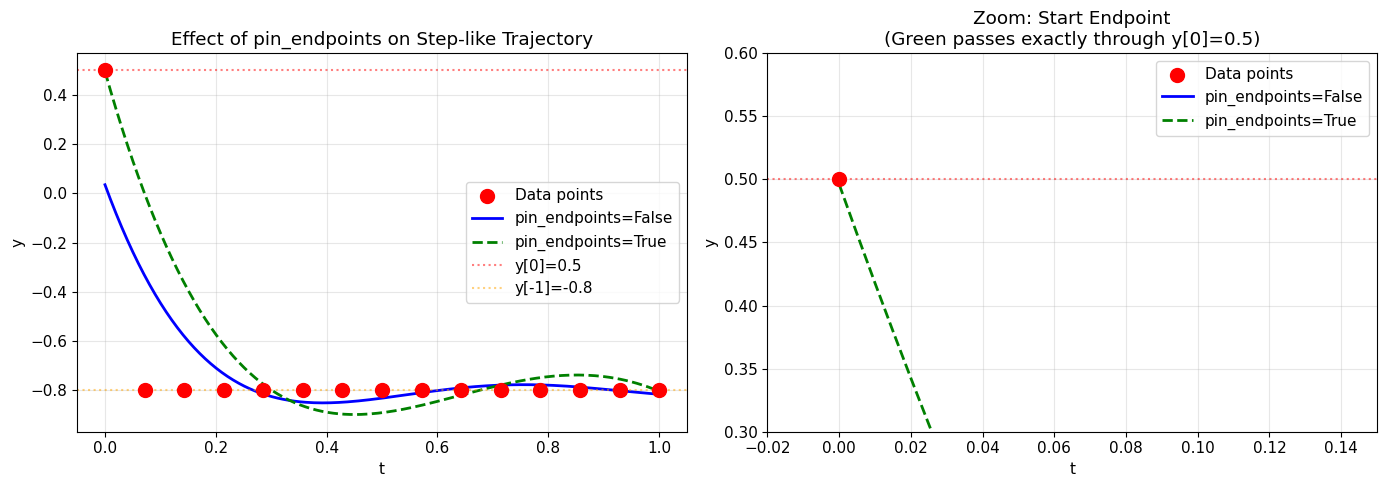

In [48]:
# Demonstrate pin_endpoints with a step-like trajectory
# where endpoints have specific non-zero values

t_step = np.linspace(0, 1, 15)
y_step = np.zeros_like(t_step)
y_step[:1] = 0.5    # Start at 0.5
y_step[1:] = -0.8  # End at -0.8

print(f"Data endpoints: y[0] = {y_step[0]}, y[-1] = {y_step[-1]}")

# Create tokenizer with fewer control points to make the difference visible
tokenizer_step = BSplineTokenizer(n_dof=1, n_control_points=5, degree=4, bounds=(-1.5, 1.5))

# Encode with and without pin_endpoints
tokens_pinned = tokenizer_step.encode(t_step, y_step.reshape(-1, 1), pin_endpoints=True)
tokens_unpinned = tokenizer_step.encode(t_step, y_step.reshape(-1, 1), pin_endpoints=False)

# Decode and evaluate
t_dense = np.linspace(0, 1, 200)
recon_pinned = tokenizer_step.decode(tokens_pinned).evaluate(t_dense)
recon_unpinned = tokenizer_step.decode(tokens_unpinned).evaluate(t_dense)

# Check endpoint values
print(f"\nWith pin_endpoints=True:")
print(f"  curve(0) = {recon_pinned[0, 0]:.4f}  (error: {abs(recon_pinned[0, 0] - y_step[0]):.4f})")
print(f"  curve(1) = {recon_pinned[-1, 0]:.4f}  (error: {abs(recon_pinned[-1, 0] - y_step[-1]):.4f})")

print(f"\nWith pin_endpoints=False:")
print(f"  curve(0) = {recon_unpinned[0, 0]:.4f}  (error: {abs(recon_unpinned[0, 0] - y_step[0]):.4f})")
print(f"  curve(1) = {recon_unpinned[-1, 0]:.4f}  (error: {abs(recon_unpinned[-1, 0] - y_step[-1]):.4f})")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(t_step, y_step, c='red', s=100, zorder=5, label='Data points')
ax.plot(t_dense, recon_unpinned[:, 0], 'b-', linewidth=2, label='pin_endpoints=False')
ax.plot(t_dense, recon_pinned[:, 0], 'g--', linewidth=2, label='pin_endpoints=True')
ax.axhline(y_step[0], color='red', linestyle=':', alpha=0.5, label=f'y[0]={y_step[0]}')
ax.axhline(y_step[-1], color='orange', linestyle=':', alpha=0.5, label=f'y[-1]={y_step[-1]}')
ax.set_xlabel('t')
ax.set_ylabel('y')
ax.set_title('Effect of pin_endpoints on Step-like Trajectory')
ax.legend()
ax.grid(True, alpha=0.3)

# Zoom on start endpoint
ax = axes[1]
ax.scatter(t_step[:3], y_step[:3], c='red', s=100, zorder=5, label='Data points')
ax.plot(t_dense[:30], recon_unpinned[:30, 0], 'b-', linewidth=2, label='pin_endpoints=False')
ax.plot(t_dense[:30], recon_pinned[:30, 0], 'g--', linewidth=2, label='pin_endpoints=True')
ax.axhline(y_step[0], color='red', linestyle=':', alpha=0.5)
ax.set_xlabel('t')
ax.set_ylabel('y')
ax.set_title('Zoom: Start Endpoint\n(Green passes exactly through y[0]=0.5)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.02, 0.15)
ax.set_ylim(0.3, 0.6)

plt.tight_layout()
plt.show()

## 7. Convenience Function Demo

Input trajectory shape: (50, 3)
Output tokens: [127 212  42 160 211  53 230 178  74 226  26 106  28  26 148  24 178 180
  94 211 201 127 212 212]
Number of tokens: 24

Tokenizer created: BSplineTokenizer(
  n_dof=3,
  n_control_points=8,
  degree=4,
  bounds=(-1.5, 1.5),
  n_bins=255,
  token_order='basis_first',
  vocab_size=255,
  n_tokens=24
)


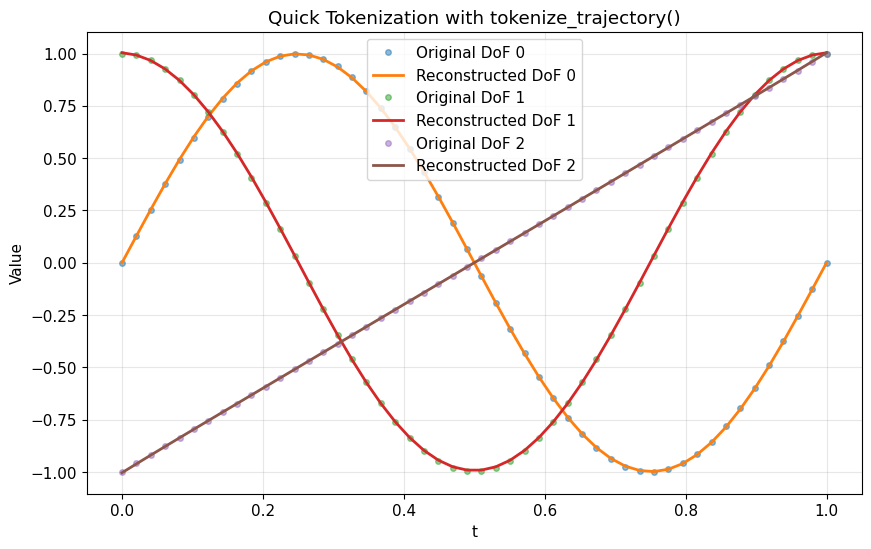

In [49]:
# Quick tokenization using convenience function
t = np.linspace(0, 1, 50)
trajectory = np.column_stack([
    np.sin(2 * np.pi * t),
    np.cos(2 * np.pi * t),
    t * 2 - 1
])

# One-liner tokenization
tokens, tokenizer = tokenize_trajectory(t, trajectory, n_control_points=8)

print(f"Input trajectory shape: {trajectory.shape}")
print(f"Output tokens: {tokens}")
print(f"Number of tokens: {len(tokens)}")
print(f"\nTokenizer created: {tokenizer}")

# Decode (chained call)
reconstructed = tokenizer.decode(tokens).evaluate(t)

# Quick visualization
fig, ax = plt.subplots(figsize=(10, 6))
for dof in range(3):
    ax.plot(t, trajectory[:, dof], 'o', markersize=4, alpha=0.5, label=f'Original DoF {dof}')
    ax.plot(t, reconstructed[:, dof], '-', linewidth=2, label=f'Reconstructed DoF {dof}')
ax.set_xlabel('t')
ax.set_ylabel('Value')
ax.set_title('Quick Tokenization with tokenize_trajectory()')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## Summary

The `BSplineTokenizer` provides:

1. **Compact representation**: 7-DoF trajectory → 56 tokens (8 control points × 7 joints)
2. **Low reconstruction error**: MAE ~0.005 for smooth trajectories
3. **Flexible token ordering**: `basis_first` or `joint_first` depending on your model architecture
4. **Bounded quantization**: Predictable token range [0, 255] for 8-bit quantization

### Recommended Settings

| Parameter | Recommended | Notes |
|-----------|-------------|-------|
| `n_control_points` | 8 | Good balance of accuracy and compactness |
| `degree` | 4 | Smooth curves with C³ continuity |
| `bounds` | (-1.5, 1.5) | For normalized trajectories in [-1, 1] |
| `n_bins` | 256 | 8-bit quantization |